In [1]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import MDS
import os
import pandas as pd

### Data Prep for Clustering

In [2]:
def load_stacked_arrays(file_paths, condition_included=None):
    """Load and stack arrays from file paths, recording the subject order."""
    mean_list = []
    loaded_subjects = []
    stacked_array = np.load(file_paths[0])

    if condition_included:
        stacked_array = stacked_array[:, :condition_included]

    mean_list.append(np.mean(stacked_array))
    loaded_subjects.append(file_paths[0].split('/')[-1])

    for file_path in file_paths[1:]:
        array = np.load(file_path)

        if condition_included:
            array = array[:, :condition_included]

        stacked_array = np.vstack((stacked_array, array))
        mean_list.append(np.mean(array))
        loaded_subjects.append(file_path.split('/')[-1])

    return stacked_array, mean_list, loaded_subjects

def load_froi_maps(file_paths):
    """Load and stack froi maps, recording the subject order."""
    froi_maps = np.load(file_paths[0])
    loaded_subjects = [file_paths[0].split('/')[-1].replace('_froi_map', '')]

    for file_path in file_paths[1:]:
        array = np.load(file_path)
        froi_maps = np.hstack((froi_maps, array))
        loaded_subjects.append(file_path.split('/')[-1].replace('_froi_map', ''))

    return list(froi_maps), loaded_subjects

def load_subject_ids(file_paths, reference_length):
    """Generate subject IDs from file paths."""
    subj_ids = []
    loaded_subjects = []

    for file_path in file_paths:
        for _ in range(reference_length):
            subj_ids.append(file_path.split('/')[-1].strip('_froi_map.npy'))
        loaded_subjects.append(file_path.split('/')[-1].replace('_froi_map', ''))

    return subj_ids, loaded_subjects

def handle_nan_values(data):
    """Set NaN values to 0 in the provided data."""
    nan_count = np.isnan(data).sum()
    print(f'NaN count: {nan_count}, setting to 0')
    data[np.isnan(data)] = 0
    return data

def plot_column_means(data, mean_list, n, labels, title):
    """Plot column means with error bars."""
    column_means = np.mean(data, axis=0)
    column_std = np.nanstd(mean_list, axis=0) / np.sqrt(n)  # Ignore NaN values

    plt.bar(labels, column_means, yerr=column_std, capsize=5)
    plt.xlabel('Column')
    plt.ylabel('Mean Value')
    plt.title(title)
    plt.show()

def load_data_swjn(data_split):
    # Define directories
    if data_split == "first_half":
        data_dir = f'/nese/mit/group/evlab/u/jshe/lang-voxel-decomp/clustering/{expt_name}/clean_matrix_five_core_rois_elizabeth_20241030'
        data_dir_langloc = f'/nese/mit/group/evlab/u/jshe/lang-voxel-decomp/clustering/{expt_name}/clean_matrix_langloc'
        data_dir_odd_conditions = f'/nese/mit/group/evlab/u/jshe/lang-voxel-decomp/clustering/{expt_name}/clean_matrix_odd_conditions'
        data_dir_even_conditions = f'/nese/mit/group/evlab/u/jshe/lang-voxel-decomp/clustering/{expt_name}/clean_matrix_even_conditions'
    elif data_split == "second_half":
        data_dir = f'/nese/mit/group/evlab/u/jshe/lang-voxel-decomp/clustering/{expt_name}/clean_matrix_second_half_subjects_five_core_rois_elizabeth_20241030'
        data_dir_langloc = f'/nese/mit/group/evlab/u/jshe/lang-voxel-decomp/clustering/{expt_name}/clean_matrix_langloc_second_half_subjects'
        data_dir_odd_conditions = f'/nese/mit/group/evlab/u/jshe/lang-voxel-decomp/clustering/{expt_name}/clean_matrix_odd_conditions_second_half_subjects'
        data_dir_even_conditions = f'/nese/mit/group/evlab/u/jshe/lang-voxel-decomp/clustering/{expt_name}/clean_matrix_even_conditions_second_half_subjects'
    else:
        raise ValueError("Invalid data_split value. Must be 'first_half' or 'second_half'.")

    # Load file paths
    file_paths_matrices = [f'{data_dir}/{file}' for file in os.listdir(data_dir) if file.endswith('PL2017.npy')]
    file_paths_froi_maps = [f'{data_dir}/{file}' for file in os.listdir(data_dir) if file.endswith('froi_map.npy')]
    file_path_matrices_langloc = [f'{data_dir_langloc}/{file}' for file in os.listdir(data_dir_langloc) if file.endswith('PL2017.npy')]
    file_path_matrices_odd_conditions = [f'{data_dir_odd_conditions}/{file}' for file in os.listdir(data_dir_odd_conditions) if file.endswith('PL2017.npy')]
    file_path_matrices_even_conditions = [f'{data_dir_even_conditions}/{file}' for file in os.listdir(data_dir_even_conditions) if file.endswith('PL2017.npy')]

    # Load data
    stacked_array, mean_list, loaded_subjects_matrices = load_stacked_arrays(file_paths_matrices, condition_included)
    stacked_array_langloc, mean_list_langloc, loaded_subjects_langloc = load_stacked_arrays(file_path_matrices_langloc)
    froi_maps, loaded_subjects_froi_maps = load_froi_maps(file_paths_froi_maps)
    reference_length = len(np.load(file_paths_froi_maps[0]))
    subj_ids, loaded_subjects_subj_ids = load_subject_ids(file_paths_froi_maps, reference_length)
    stacked_array_odd_conditions, mean_list_odd_conditions, loaded_subjects_odd_conditions = load_stacked_arrays(file_path_matrices_odd_conditions, condition_included)
    stacked_array_even_conditions, mean_list_even_conditions, loaded_subjects_even_conditions = load_stacked_arrays(file_path_matrices_even_conditions, condition_included)

    # Verify subject order
    if not (loaded_subjects_matrices == loaded_subjects_langloc == loaded_subjects_froi_maps == loaded_subjects_odd_conditions == loaded_subjects_even_conditions):
        raise ValueError("Mismatch in subject order across data types.")

    # Handle NaN values
    data_all = handle_nan_values(stacked_array)
    data_langloc = stacked_array_langloc
    data_odd_conditions = handle_nan_values(stacked_array_odd_conditions)
    data_even_conditions = handle_nan_values(stacked_array_even_conditions)

    return {
        'stacked_array': data_all,
        'froi_maps': froi_maps,
        'subj_ids': subj_ids,
        'langloc_conds': data_langloc,
        'odd_conds': data_odd_conditions,
        'even_conds': data_even_conditions,
        'mean_list': mean_list,
        'mean_list_langloc': mean_list_langloc,
        'mean_list_odd_conditions': mean_list_odd_conditions,
        'mean_list_even_conditions': mean_list_even_conditions
    }


def load_data_swjn_main():
    data_split = "all"  # Options: "first_half", "second_half", "all"
    condition_included = 4
    
    if data_split == "all":
        n_participant = 22
        first_half_data = load_data("first_half")
        second_half_data = load_data("second_half")

        data_all = np.vstack((first_half_data['stacked_array'], second_half_data['stacked_array']))
        froi_maps = first_half_data['froi_maps'] + second_half_data['froi_maps']
        subj_ids = first_half_data['subj_ids'] + second_half_data['subj_ids']
        data_langloc = np.vstack((first_half_data['langloc_conds'], second_half_data['langloc_conds']))
        data_odd_conditions = np.vstack((first_half_data['odd_conds'], second_half_data['odd_conds']))
        data_even_conditions = np.vstack((first_half_data['even_conds'], second_half_data['even_conds']))

        mean_list = first_half_data['mean_list'] + second_half_data['mean_list']
        mean_list_langloc = first_half_data['mean_list_langloc'] + second_half_data['mean_list_langloc']
        mean_list_odd_conditions = first_half_data['mean_list_odd_conditions'] + second_half_data['mean_list_odd_conditions']
        mean_list_even_conditions = first_half_data['mean_list_even_conditions'] + second_half_data['mean_list_even_conditions']
    else:
        n_participant = 11
        loaded_data = load_data(data_split)
        data_all = loaded_data['stacked_array']
        froi_maps = loaded_data['froi_maps']
        subj_ids = loaded_data['subj_ids']
        data_langloc = loaded_data['langloc_conds']
        data_odd_conditions = loaded_data['odd_conds']
        data_even_conditions = loaded_data['even_conds']

        mean_list = loaded_data['mean_list']
        mean_list_langloc = loaded_data['mean_list_langloc']
        mean_list_odd_conditions = loaded_data['mean_list_odd_conditions']
        mean_list_even_conditions = loaded_data['mean_list_even_conditions']


    # Plot results
    plot_column_means(data_all, mean_list, n=n_participant, labels=['S', 'W', 'JS', 'NW', 'BS', 'NS'], title=f'Mean Values of Each Column (EVEN+ODD); data_split: {data_split}')
    plot_column_means(data_even_conditions, mean_list_even_conditions, n=n_participant, labels=['S', 'W', 'JS', 'NW', 'BS', 'NS'], title=f'Mean Values of Each Column (EVEN); data_split: {data_split}')
    plot_column_means(data_odd_conditions, mean_list_odd_conditions, n=n_participant, labels=['S', 'W', 'JS', 'NW', 'BS', 'NS'], title=f'Mean Values of Each Column (ODD); data_split: {data_split}')
    plot_column_means(data_langloc, mean_list_langloc, n=n_participant, labels=['S', 'N'], title=f'Mean Values of Each Column (langlocSN); data_split: {data_split}')

    # Print results
    print('data_all:', data_all.shape)
    print('froi_maps:', len(froi_maps))
    print('subj_ids:', len(subj_ids))
    print('data_langloc:', data_langloc.shape)
    print('odd_conds:', data_odd_conditions.shape)
    print('even_conds:', data_even_conditions.shape)


def load_data_new(data_split, expt_name, condition_included):
    # Define directories
    if data_split == "all":
        data_dir = f'/nese/mit/group/evlab/u/jshe/lang-voxel-decomp/clustering/{expt_name}/clean_matrix_all_runs'
    else:
        raise ValueError("Invalid data_split value. Must be 'first_half' or 'second_half'.")

    # Load file paths
    file_paths_matrices = [f'{data_dir}/{file}' for file in os.listdir(data_dir) if file.endswith('PL2017.npy')]
    file_paths_froi_maps = [f'{data_dir}/{file}' for file in os.listdir(data_dir) if file.endswith('froi_map.npy')]

    # Load data
    stacked_array, mean_list, loaded_subjects_matrices = load_stacked_arrays(file_paths_matrices, condition_included)
    froi_maps, loaded_subjects_froi_maps = load_froi_maps(file_paths_froi_maps)
    reference_length = len(np.load(file_paths_froi_maps[0]))
    subj_ids, loaded_subjects_subj_ids = load_subject_ids(file_paths_froi_maps, reference_length)
    
    # Verify subject order
    if not (loaded_subjects_matrices == loaded_subjects_froi_maps == loaded_subjects_subj_ids):
        raise ValueError("Mismatch in subject order across data types.")

    # Handle NaN values
    data_all = handle_nan_values(stacked_array)
    
    return {
        'stacked_array': data_all,
        'froi_maps': froi_maps,
        'subj_ids': subj_ids,
        'mean_list': mean_list,
    }

def load_data_nlength_main():
    loaded_data = load_data('all')
    data_all, mean_list, subj_ids, froi_maps = loaded_data['stacked_array'], loaded_data['mean_list'], loaded_data['subj_ids'], loaded_data['froi_maps']
    plot_column_means(data_all, mean_list, n=n_participant, labels=['S', 'W', 'JS', 'NW'], title=f'Mean Values of Each Column (EVEN+ODD); data_split: {data_split}')
    print('data_all:', data_all.shape)
    print('froi_maps:', len(froi_maps))
    print('subj_ids:', len(subj_ids))

#### Load subjects

NaN count: 8, setting to 0
NaN count: 76, setting to 0
NaN count: 0, setting to 0


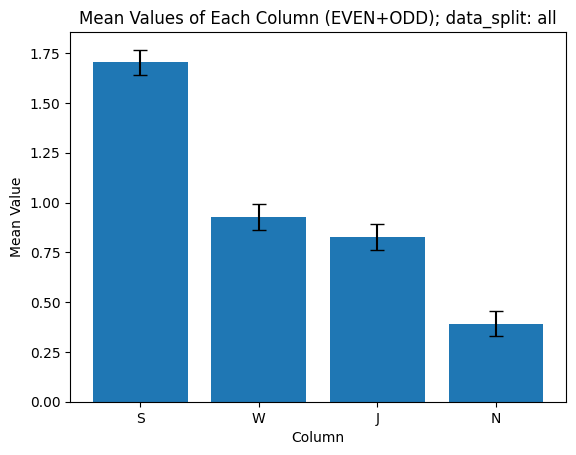

data_all: (53944, 4)
froi_maps: 53944
subj_ids: 53944


In [3]:
# THREE DATASETS COMBINED

expt_names = ['SWJN_deluxe', 'Nlength_con2', 'SWJNV2']
n_participant = 22+40+26
condition_included = 4
column_names = ['S', 'W', 'J', 'N']

SWJN_deluxe_data = load_data_new('all', 'SWJN_deluxe', 4)
Nlength_con2_data = load_data_new('all', 'Nlength_con2', 4)
SWJNV2_data = load_data_new('all', 'SWJNV2', 4)

data_all = np.vstack((SWJN_deluxe_data['stacked_array'], Nlength_con2_data['stacked_array'], SWJNV2_data['stacked_array']))
froi_maps = SWJN_deluxe_data['froi_maps'] + Nlength_con2_data['froi_maps'] + SWJNV2_data['froi_maps']
subj_ids = SWJN_deluxe_data['subj_ids'] + Nlength_con2_data['subj_ids'] + SWJNV2_data['subj_ids']
mean_list = SWJN_deluxe_data['mean_list'] + Nlength_con2_data['mean_list'] + SWJNV2_data['mean_list']

plot_column_means(data_all, mean_list, n=n_participant, labels=column_names, title=f'Mean Values of Each Column (EVEN+ODD); data_split: all')
print('data_all:', data_all.shape)
print('froi_maps:', len(froi_maps))
print('subj_ids:', len(subj_ids))

In [ ]:
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
# from gap_statistic import OptimalK
import matplotlib.pyplot as plt

data = data_all
data_normalized = data

# Range of clusters to test
k_range = range(2, 11)  # Adjust as needed

# Metrics storage
silhouette_scores = []
calinski_scores = []
davies_bouldin_scores = []
wcss_values = []

# Calculate metrics for each k
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data_normalized)

    # Silhouette Score
    silhouette_avg = silhouette_score(data_normalized, labels)
    silhouette_scores.append(silhouette_avg)

    # Calinski-Harabasz Index
    calinski_avg = calinski_harabasz_score(data_normalized, labels)
    calinski_scores.append(calinski_avg)

    # Davies-Bouldin Index
    davies_bouldin_avg = davies_bouldin_score(data_normalized, labels)
    davies_bouldin_scores.append(davies_bouldin_avg)

    # Within-Cluster Sum of Squares (WCSS)
    wcss = kmeans.inertia_
    wcss_values.append(wcss)

# Visualization
plt.figure(figsize=(20, 10))

# Silhouette Scores
plt.subplot(2, 2, 1)
plt.plot(k_range, silhouette_scores, marker='o')
plt.title('Silhouette Score')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Score')

# Calinski-Harabasz Index
plt.subplot(2, 2, 2)
plt.plot(k_range, calinski_scores, marker='o')
plt.title('Calinski-Harabasz Index')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Score')

# Davies-Bouldin Index
plt.subplot(2, 2, 3)
plt.plot(k_range, davies_bouldin_scores, marker='o')
plt.title('Davies-Bouldin Index')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Score')

# WCSS
plt.subplot(2, 2, 4)
plt.plot(k_range, wcss_values, marker='o')
plt.title('Within-Cluster Sum of Squares (WCSS)')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')

plt.tight_layout()
plt.show()

# # Print Gap Statistics results
# print("Gap Statistics Optimal k:", gap_stats)


ValueError: Number of labels is 1. Valid values are 2 to n_samples - 1 (inclusive)

##### Sanity check #2

Can we do another sanity check: for the 6 values (condition-level responses in the lang areas, across all data), can we look at the similarity of each participant’s profile to the average of the rest of the participants? So this would be a set of r values, one per participant, where each r is computed simply across two sets of 6 values. Does this make sense?

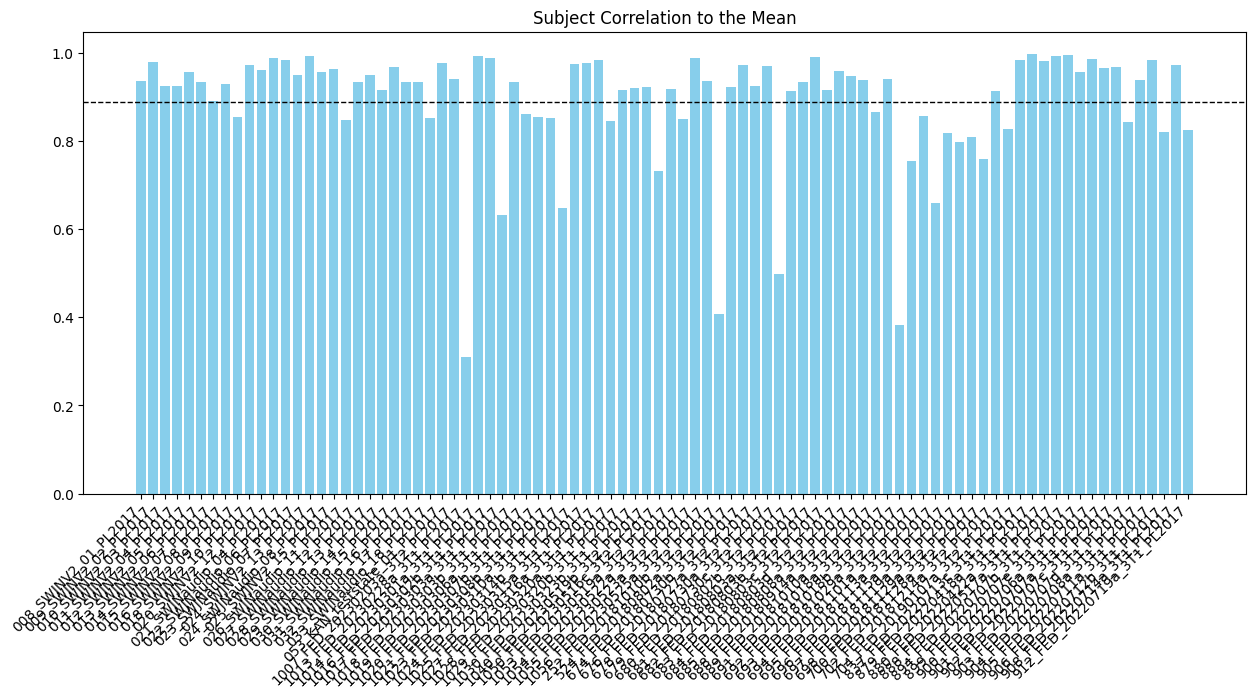

In [21]:
df_sanity_check = pd.DataFrame(data_all, columns=column_names)
df_sanity_check['subject'] = subj_ids

# Step 1: Calculate men values per subject
subject_means = df_sanity_check.groupby('subject')[column_names].mean()

# Step 2: Calculate the grand mean across all subjects for each condition
grand_mean = subject_means.mean()

# Step 3: Compute correlation for each subject with the grand mean
def compute_correlation(row, grand_mean):
    return row.corr(grand_mean)

# Apply the correlation function to each subject's mean values
subject_means['correlation_with_grand_mean'] = subject_means.apply(
    lambda row: compute_correlation(row, grand_mean), axis=1
)

subject_means = subject_means.reset_index()
plt.figure(figsize=(15, 6))
plt.bar(subject_means['subject'], subject_means['correlation_with_grand_mean'], color='skyblue')
plt.axhline(y=subject_means['correlation_with_grand_mean'].mean(), color='black', linestyle='--', linewidth=1)  # Customize the line as needed
plt.xticks(rotation=45, ha='right')
plt.title('Subject Correlation to the Mean')
plt.show()

##### Defining clustering conditions

In [8]:
conditions_for_clustering = 4

data_for_clustering = data_all[:,:conditions_for_clustering]
# data_odd_conditions_for_clustering = data_odd_conditions[:,:conditions_for_clustering]
# data_even_conditions_for_clustering = data_even_conditions[:,:conditions_for_clustering]

##### Plotting elbow graphs to determine optimal k

In [4]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

def plot_elbow_graph(data, max_k=10):
    """
    Plots an elbow graph for K-means clustering using SSE and Silhouette Score.
    
    Parameters:
        data (array-like): Dataset for clustering.
        max_k (int): Maximum number of clusters to evaluate. Default is 10.
    """
    sse = []  # Sum of Squared Errors (Inertia)
    silhouette_scores = []  # Silhouette Scores

    # Evaluate clusters from 1 to max_k
    for k in range(1, max_k + 1):
        kmeans = KMeans(n_clusters=k, random_state=42)
        kmeans.fit(data)
        sse.append(kmeans.inertia_)

        # Silhouette score is valid only for k > 1
        if k > 1:
            silhouette_scores.append(silhouette_score(data, kmeans.labels_))
        else:
            silhouette_scores.append(None)  # Placeholder for k = 1
    print(silhouette_scores)
    # Plot SSE (Inertia)
    plt.figure(figsize=(14, 6))
    plt.plot(range(1, max_k + 1), sse, marker='o', label='SSE (Inertia)')
    plt.title('Elbow Method for Optimal K')
    plt.xlabel('Number of clusters (k)')
    plt.ylabel('SSE (Inertia)')
    plt.xticks(range(1, max_k + 1))
    plt.grid(True)
    plt.legend()
    plt.show()

plot_elbow_graph(data_for_clustering)

NameError: name 'data_for_clustering' is not defined

#### Clustering with optimal K (K means)

##### clustering with all, even, and odd runs

/nese/mit/group/evlab/u/jshe/anaconda/envs/nlp/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


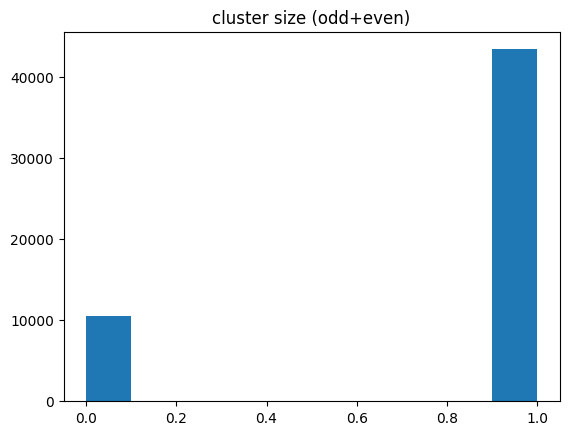

In [22]:
# Choose the optimal number of clusters based on the elbow plot
optimal_k = 2

# Apply k-means clustering with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
clusters = kmeans.fit_predict(data_for_clustering)

plt.hist(clusters)
plt.title('cluster size (odd+even)')
plt.show()

# # Cluster with odd runs data
# kmeans = KMeans(n_clusters=optimal_k, random_state=42)
# clusters_odd = kmeans.fit_predict(data_odd_conditions_for_clustering)

# plt.hist(clusters_odd)
# plt.title('cluster size (odd)')
# plt.show()

# # Cluster with even runs data
# kmeans = KMeans(n_clusters=optimal_k, random_state=42)
# clusters_even = kmeans.fit_predict(data_even_conditions_for_clustering)

# plt.hist(clusters_even)
# plt.title('cluster size (even)')
# plt.show()

#### Prepping big dataframe for analysis and plotting

In [23]:
mapping_dict = {
    1: "LH_IFGorb",
    2: "LH_IFG",
    3: "LH_MFG",
    4: "LH_AntTemp",
    5: "LH_PostTemp"
}

data_plotting = pd.DataFrame(data_all, columns=column_names)

# Assign cluster labels to the original data
data_plotting['cluster'] = clusters

# data_plotting['cluster_odd'] = clusters_odd
# data_plotting['cluster_even'] = clusters_even

# Assign froi ids
data_plotting['fROI_index'] = froi_maps
data_plotting['fROI_region'] = data_plotting['fROI_index'].map(mapping_dict)

# # Assign langloc voxel activations
# data_plotting['S_langloc'] = data_langloc[:, 0]
# data_plotting['N_langloc'] = data_langloc[:, 1]

# Assign subj id
data_plotting['subj_id'] = subj_ids

data_plotting

,S,W,J,N,cluster,fROI_index,fROI_region,subj_id
0,0.317512,-0.186648,-0.562768,-0.306428,1,5.0,LH_PostTemp,1007_FED_20230203a_3T2_PL2017
1,0.237754,-0.241508,-0.636382,-0.506090,1,5.0,LH_PostTemp,1007_FED_20230203a_3T2_PL2017
2,-0.152216,-0.515502,-0.874912,-0.800496,1,5.0,LH_PostTemp,1007_FED_20230203a_3T2_PL2017
3,0.238238,-0.530231,-0.893432,-0.553538,1,5.0,LH_PostTemp,1007_FED_20230203a_3T2_PL2017
4,0.060794,-0.675608,-1.056015,-0.755838,1,5.0,LH_PostTemp,1007_FED_20230203a_3T2_PL2017
...,...,...,...,...,...,...,...,...
53939,0.595203,-0.014131,0.307358,0.061146,1,5.0,LH_PostTemp,053_KAN_reststate_01_PL2017
53940,-0.071259,-0.234237,-0.404742,-0.635088,1,4.0,LH_AntTemp,053_KAN_reststate_01_PL2017
53941,0.726938,0.200993,0.616658,0.191720,1,5.0,LH_PostTemp,053_KAN_reststate_01_PL2017
53942,1.249062,0.505657,0.925479,0.744619,1,5.0,LH_PostTemp,053_KAN_reststate_01_PL2017


#### Plotting

##### Cluster profiles


In [27]:
numeric_columns_paramnew = ['S (S)', 'W (W)', 'N (W4)']

In [24]:
# plotting functions

def plot_cluster_profile(cluster_column, plot_title_label):
    # Select numeric columns and cluster for aggregation
    numeric_columns = column_names
    
    data_plotting_numeric = data_plotting[numeric_columns + [cluster_column]]

    # Calculate the average and standard deviation for each cluster
    cluster_stats = data_plotting_numeric.groupby(cluster_column).agg(['mean', 'std'])

    # Extract the mean and standard deviation for plotting
    cluster_means = cluster_stats.xs('mean', axis=1, level=1)
    cluster_stds = cluster_stats.xs('std', axis=1, level=1)
    cluster_stds = cluster_stds/np.sqrt(n_participant)

    # Plot the averages as bar graphs with error bars
    ax = cluster_means.plot(kind='bar', yerr=cluster_stds, figsize=(10, 7), capsize=4)
    plt.title(f'Average Responses by Cluster ({plot_title_label})')
    plt.xlabel('Cluster')
    plt.ylabel('Average Responses')
    plt.legend(title='Condition', loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()


def plot_odd_even_line_graph():
    # Select numeric columns and cluster for aggregation
    numeric_columns = ['S', 'W', 'JS', 'NW', 'BS', 'NS', 'S_langloc', 'N_langloc']
    data_numeric_odd = data_plotting[numeric_columns + ['cluster_odd_manual_matched']]
    data_numeric_even = data_plotting[numeric_columns + ['cluster_even_manual_matched']]

    # Calculate the average and standard deviation for each cluster for both DataFrames
    cluster_means_odd = data_numeric_odd.groupby('cluster_odd_manual_matched').mean()
    cluster_means_even = data_numeric_even.groupby('cluster_even_manual_matched').mean()

    # Define the grid layout
    num_clusters = len(cluster_means_odd.index)
    rows, cols = 2,2  # Adjust rows and columns for the number of clusters
    fig, axes = plt.subplots(rows, cols, figsize=(16, 12))  # Create a grid of subplots
    axes = axes.flatten()  # Flatten the axes array for easier indexing

    # Loop through each cluster and create a plot in the grid
    for i, cluster in enumerate(cluster_means_odd.index):
        ax = axes[i]  # Select the corresponding subplot
        
        for condition in numeric_columns:
            # Plot a line connecting the odd and even means for the same condition and cluster
            ax.plot(
                [1, 2],  # x-axis for odd and even
                [cluster_means_odd.loc[cluster, condition], cluster_means_even.loc[cluster, condition]], 
                marker='o', 
                label=f'{condition}' if i == 0 else None  # Add legend only to the first plot
            )
        
        # Customize each subplot
        ax.set_xticks([1, 2])
        ax.set_xticklabels(['ODD', 'EVEN'])
        ax.set_title(f'Cluster {cluster}')
        ax.set_xlabel('Run')
        ax.set_ylabel('Mean Activation')
        ax.grid(True)

    # Add a single legend for the whole figure
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Condition', loc='upper right', bbox_to_anchor=(1.15, 0.95))

    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(right=0.85)  # Adjust space for the legend
    plt.show()

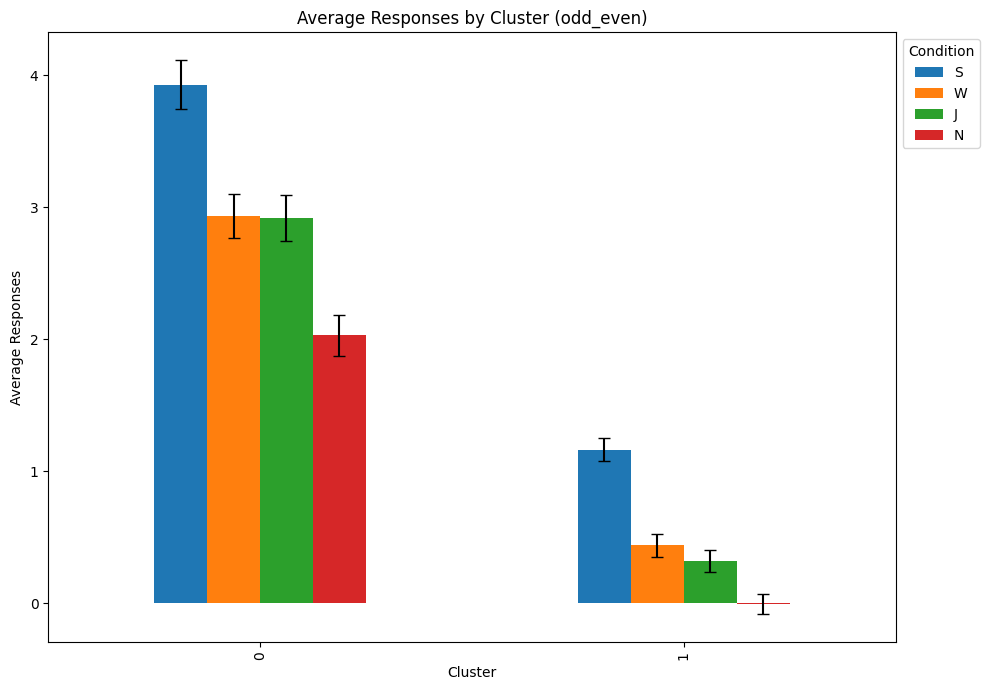

In [25]:
plot_cluster_profile('cluster', 'odd_even')
# plot_cluster_profile('cluster_odd', 'odd')
# plot_cluster_profile('cluster_even', 'even')

In [26]:
######### MANUAL REMEMBER TO DO THIS #########
# cluster_label_mapping = {
#     0: 'low',
#     1: 'med',
#     2: 'INT',
#     3: 'high'
# }

# cluster_label_mapping = {
#     0: 'low',
#     1: 'med_1',
#     2: 'INT',
#     3: 'high',
#     4: 'med_2',
#     5: 'med_3'
# }

cluster_label_mapping = {
    0: 'high',
    1: 'low'
}

##############################################

##### Proportions of rois in each cluster and vice versa

Here is what I think we want to do:

i) For each cluster (derived from across all participants), look for each participant at how many voxels come from each of the five fROIs; we might want to do proportions instead of raw voxels, to control for diffs in fROI sizes.

E.g., if you have 100 voxels for a participant, and for cluster 1, you have 50 voxels coming from LPostTemp and 30 voxels coming from LAntTemp, and 0 voxels from the frontal fROIs, we would have:

posttemp .5
anttemp .3
ifg 0
ifgorb 0
mfg 0

The final result will be — for each cluster — info on the avg contribution from each of the 5 fROIs.

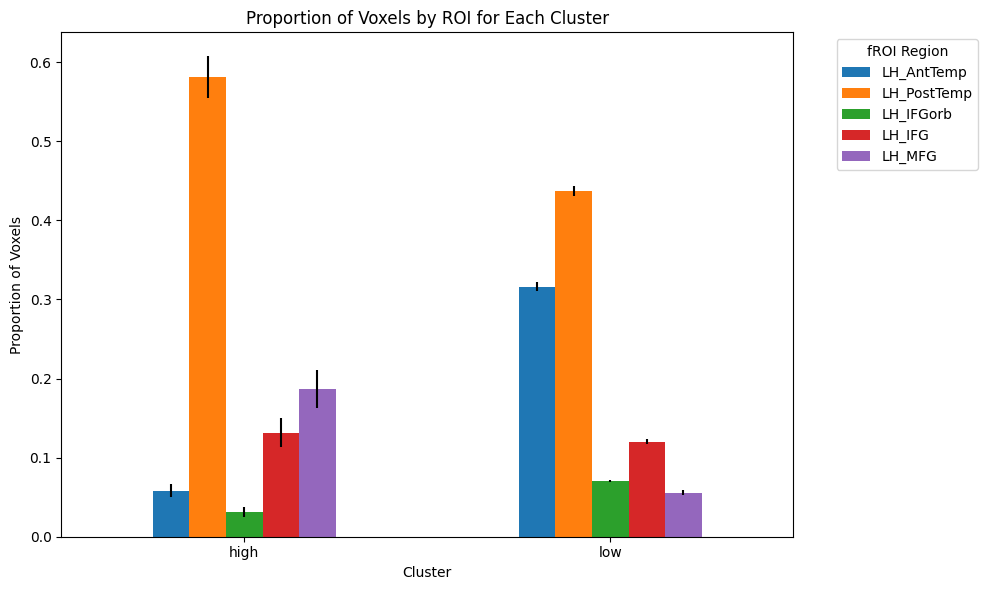

In [27]:
# Desired order for fROI regions
desired_order = ['LH_AntTemp', 'LH_PostTemp', 'LH_IFGorb', 'LH_IFG', 'LH_MFG']

# Convert to DataFrame
df_proportions = data_plotting

# Initialize the result dataframe
unique_subj_ids = df_proportions["subj_id"].unique()
unique_rois = df_proportions["fROI_region"].unique()
result_df = pd.DataFrame(columns=["subj_id", "cluster"] + list(unique_rois))

# Calculate proportions for each subject and cluster
for subj_id in unique_subj_ids:
    for cluster in df_proportions["cluster"].unique():
        # Filter by subject and cluster
        subj_cluster_df = df_proportions[(df_proportions["subj_id"] == subj_id) & (df_proportions["cluster"] == cluster)]
        
        # Total count for this subject and cluster
        total_voxels = len(subj_cluster_df)
        
        # Calculate proportion for each ROI
        row = {"subj_id": subj_id, "cluster": cluster}
        for roi in unique_rois:
            roi_count = len(subj_cluster_df[subj_cluster_df["fROI_region"] == roi])
            proportion = roi_count / total_voxels if total_voxels > 0 else 0
            row[roi] = proportion
        
        # Append row to result dataframe
        result_df = pd.concat([result_df, pd.DataFrame([row])], ignore_index=True)
        
# Calculate mean and SEM across subjects
mean_across_subjs = result_df.groupby('cluster')[list(unique_rois)].mean()
sem_across_subjs = result_df.groupby('cluster')[list(unique_rois)].sem()

# Reorder columns based on desired order
mean_across_subjs = mean_across_subjs[desired_order]
sem_across_subjs = sem_across_subjs[desired_order]

# Plotting the bar chart
ax = mean_across_subjs.plot(kind="bar", figsize=(10, 6), yerr=sem_across_subjs)
plt.title("Proportion of Voxels by ROI for Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Proportion of Voxels")
plt.legend(title="fROI Region", bbox_to_anchor=(1.05, 1), loc="upper left")

# Modify xticks labels according to the cluster_label_mapping
xticks = ax.get_xticks()
new_labels = [cluster_label_mapping[int(label)] for label in xticks]
ax.set_xticklabels(new_labels, rotation=0)

plt.tight_layout()
plt.show()


ii) for each fROI, look for each participant at how many voxels contribute to each of the 4 clusters.

E.g., if you have 100 voxels for LPostTemp in a given participant, and find that 80 voxels contribute to cluster 1, 10 voxels to cluster 2, and and 5 voxels to each of the remaining two clusters, so we would have:

cluster 1 .8
cluster 2 .1
cluster 3 .05
cluster 4 .05

The final result will be — for each fROI — info on the avg contribution of voxels from that fROI to each of the 4 clusters.

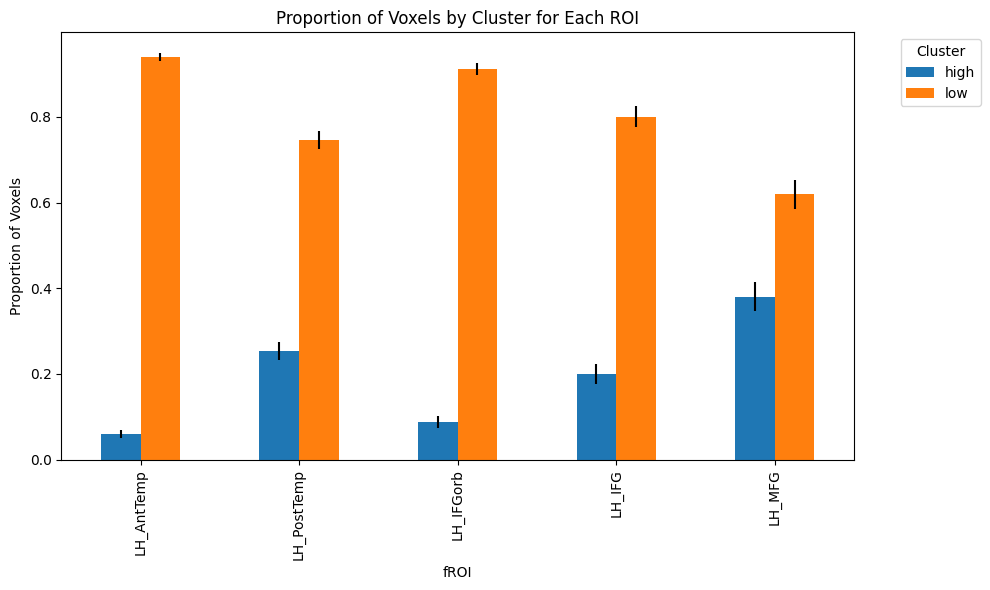

In [29]:
# Desired order for fROI regions and clusters
desired_fROI_order = ['LH_AntTemp', 'LH_PostTemp', 'LH_IFGorb', 'LH_IFG', 'LH_MFG']
desired_cluster_order = ['cluster_0', 'cluster_1']

# Initialize the result dataframe for each ROI and proportion of clusters for each subject
df = data_plotting

unique_subj_ids = df["subj_id"].unique()
unique_rois = df["fROI_region"].unique()
unique_clusters = df["cluster"].unique()

# Result dataframe columns
result_columns = ["subj_id", "fROI_region"] + [f"cluster_{cluster}" for cluster in unique_clusters]
result_df = pd.DataFrame(columns=result_columns)

# Calculate proportions for each subject, ROI, and cluster
for subj_id in unique_subj_ids:
    for roi in unique_rois:
        # Filter by subject and ROI
        subj_roi_df = df[(df["subj_id"] == subj_id) & (df["fROI_region"] == roi)]
        
        # Total count for this subject and ROI
        total_voxels = len(subj_roi_df)
        
        # Initialize row with subject ID and ROI
        row = {"subj_id": subj_id, "fROI_region": roi}
        
        # Calculate proportion for each cluster
        for cluster in unique_clusters:
            cluster_count = len(subj_roi_df[subj_roi_df["cluster"] == cluster])
            proportion = cluster_count / total_voxels if total_voxels > 0 else 0
            row[f"cluster_{cluster}"] = proportion
        
        # Append row to result dataframe
        result_df = pd.concat([result_df, pd.DataFrame([row])], ignore_index=True)

# Calculate mean and SEM across subjects
mean_across_subjs = result_df.groupby('fROI_region')[[f"cluster_{cluster}" for cluster in unique_clusters]].mean()
sem_across_subjs = result_df.groupby('fROI_region')[[f"cluster_{cluster}" for cluster in unique_clusters]].sem()

# Reorder rows and columns based on desired order
mean_across_subjs = mean_across_subjs.loc[desired_fROI_order, desired_cluster_order]
sem_across_subjs = sem_across_subjs.loc[desired_fROI_order, desired_cluster_order]

# Rename columns using cluster_label_mapping
new_column_names = {f"cluster_{cluster}": cluster_label_mapping[cluster] for cluster in unique_clusters}
mean_across_subjs.rename(columns=new_column_names, inplace=True)
sem_across_subjs.rename(columns=new_column_names, inplace=True)

# Plotting the bar chart
mean_across_subjs.plot(kind="bar", figsize=(10, 6), yerr=sem_across_subjs)
plt.title("Proportion of Voxels by Cluster for Each ROI")
plt.xlabel("fROI")
plt.ylabel("Proportion of Voxels")
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

##### Cluster size with sem bars

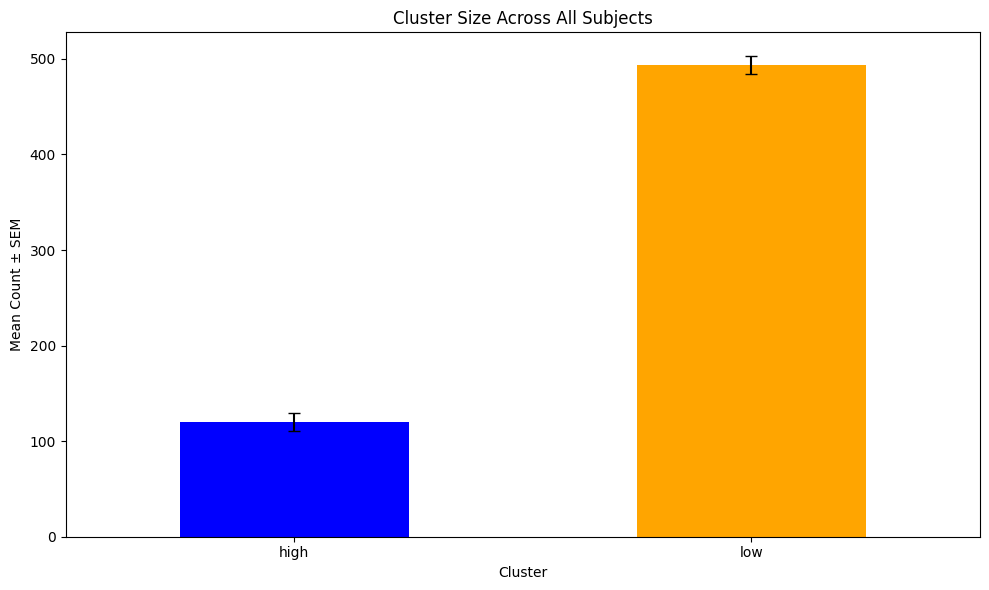

In [30]:
# Group data to count clusters per subject
result = data_plotting.groupby(['subj_id', 'cluster']).size().reset_index(name='count')

# Pivot table for easier computation
pivot_df = result.pivot(index="subj_id", columns="cluster", values="count").fillna(0)

# Calculate mean and SEM for each cluster
mean_values = pivot_df.mean(axis=0)
sem_values = pivot_df.std(axis=0)/np.sqrt(n_participant)

# # Define the desired cluster order: low (0), INT (1), med (3), high (2)
# desired_order = [0, 1, 3, 2]

# # Reorder the mean and SEM values according to the desired order
# mean_ordered = mean_values[desired_order]
# sem_ordered = sem_values[desired_order]

# Plotting mean values with error bars
ax = mean_values.plot(
    kind="bar", 
    yerr=sem_values, 
    figsize=(10, 6), 
    capsize=4, 
    color=['blue', 'orange', 'green', 'red']  # Optional: customize colors
)

plt.xlabel("Cluster")
plt.ylabel("Mean Count ± SEM")
plt.title("Cluster Size Across All Subjects")
plt.xticks(rotation=0)

# xticks = ax.get_xticks()
# new_labels = [cluster_label_mapping[int(label)] for label in xticks]
# ax.set_xticklabels(new_labels)
ax.set_xticklabels([cluster_label_mapping[cluster] for cluster in [0,1]])

# Modify legend labels
plt.tight_layout()
plt.show()

##### Line graph marking odd-even changes in profiles

In [31]:
# MANUAL MAPPING

# clustering_matching_odd_to_even = {0:0, 1:2, 2:3, 3:1}
clustering_matching_odd_to_even = {0:2, 1:3, 2:1, 3:0}

data_plotting['cluster_odd_manual_matched'] = data_plotting['cluster_odd'].map(clustering_matching_odd_to_even)
data_plotting['cluster_even_manual_matched'] = data_plotting['cluster_even']

plot_cluster_profile('cluster_odd_manual_matched', 'odd_matched')
plot_cluster_profile('cluster_even_manual_matched', 'even_matched')
plot_odd_even_line_graph()

KeyError: 'cluster_odd'

##### Cluster profiles by fROI

/tmp/ipykernel_253237/166491447.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_0_data['fROI_region'] = pd.Categorical(


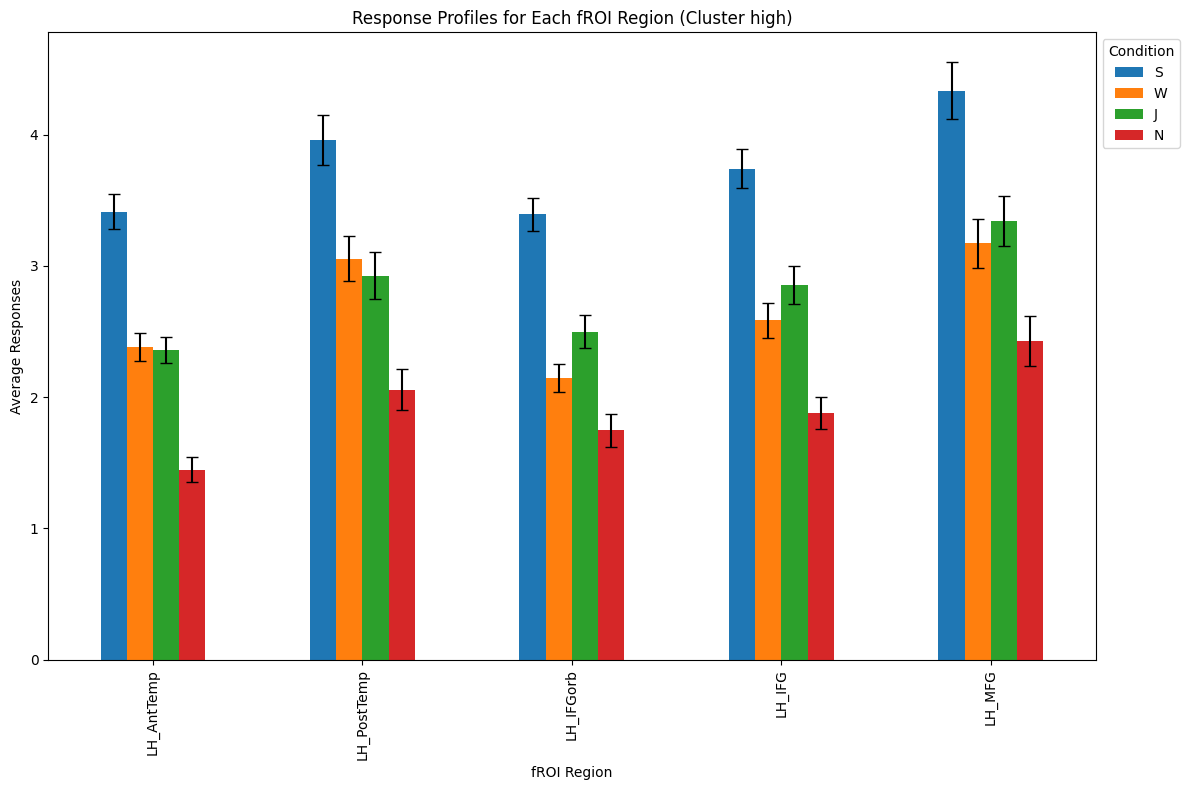

/tmp/ipykernel_253237/166491447.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cluster_0_data['fROI_region'] = pd.Categorical(


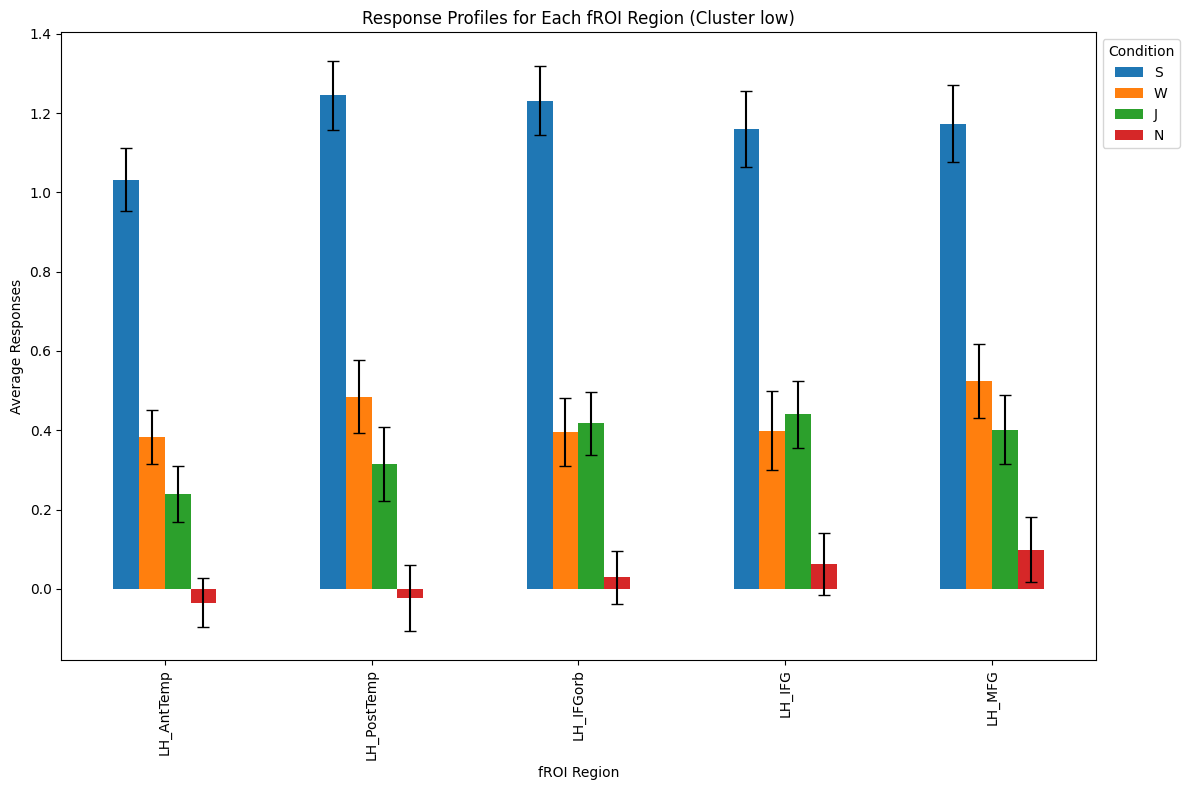

/nese/mit/group/evlab/u/jshe/anaconda/envs/nlp/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1185: RuntimeWarning: All-NaN axis encountered
  miny = np.nanmin(masked_verts[..., 1])
/nese/mit/group/evlab/u/jshe/anaconda/envs/nlp/lib/python3.11/site-packages/matplotlib/axes/_axes.py:1186: RuntimeWarning: All-NaN axis encountered
  maxy = np.nanmax(masked_verts[..., 1])


KeyError: 2

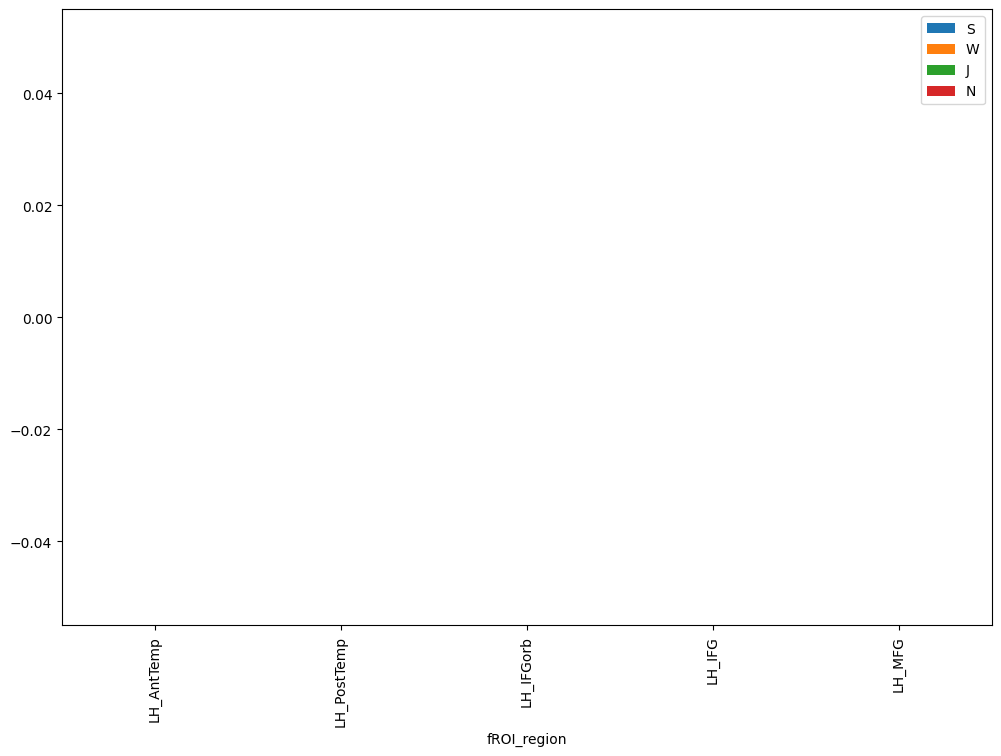

In [32]:
desired_order = ['LH_AntTemp', 'LH_PostTemp', 'LH_IFGorb', 'LH_IFG', 'LH_MFG']
numeric_columns = column_names

def plot_cluster_profile_by_froi(cluster_id, cluster_column):

    # Filter for cluster 0
    cluster_0_data = data_plotting[data_plotting[cluster_column] == cluster_id]

    # Ensure fROI_region follows the desired order
    cluster_0_data['fROI_region'] = pd.Categorical(
        cluster_0_data['fROI_region'], 
        categories=desired_order, 
        ordered=True
    )

    # Group by fROI_region and calculate the mean and SEM for each region
    fROI_stats = cluster_0_data.groupby('fROI_region')[numeric_columns].agg(['mean', 'std'])

    # Extract the mean and SEM for plotting
    fROI_means = fROI_stats.xs('mean', axis=1, level=1)
    fROI_stds = fROI_stats.xs('std', axis=1, level=1)
    fROI_sems = fROI_stds/np.sqrt(n_participant)

    # Plot the response profiles for each fROI_region
    ax = fROI_means.loc[desired_order].plot(
        kind='bar', 
        yerr=fROI_sems.loc[desired_order], 
        figsize=(12, 8), 
        capsize=4, 
        legend=True
    )
    plt.title(f'Response Profiles for Each fROI Region (Cluster {cluster_label_mapping[cluster_id]})')
    plt.xlabel('fROI Region')
    plt.ylabel('Average Responses')
    plt.legend(title='Condition', loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

# Plotting by cluster
for cluster in [0,1,2,3,4,5]:
    plot_cluster_profile_by_froi(cluster, 'cluster')

### Archived

##### Plot all cluster by froi

In [ ]:
def plot_all_clusters_profile_by_froi(cluster_column):
    
    # Initialize the figure
    fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=True)
    axes = axes.flatten()

    # Loop through cluster IDs and create a plot for each
    for cluster_id, ax in zip(range(4), axes):
        # Subset data for the current cluster
        cluster_data = data_plotting[data_plotting[cluster_column] == cluster_id]
        
        # Ensure fROI_region follows the desired order
        cluster_data['fROI_region'] = pd.Categorical(
            cluster_data['fROI_region'], 
            categories=desired_order, 
            ordered=True
        )
        
        # Group by fROI_region and calculate the mean and SEM for each region
        fROI_stats = cluster_data.groupby('fROI_region')[numeric_columns].agg(['mean', 'std'])
        
        # Extract the mean and SEM for plotting
        fROI_means = fROI_stats.xs('mean', axis=1, level=1)
        fROI_stds = fROI_stats.xs('std', axis=1, level=1)
        fROI_sems = fROI_stds/np.sqrt(11)
        
        # Plot the response profiles for the current cluster
        fROI_means.loc[desired_order].plot(
            kind='bar',
            yerr=fROI_sems.loc[desired_order],
            ax=ax,
            capsize=4,
            legend=(cluster_id == 0)  # Show legend only for the first plot
        )
        
        ax.set_title(f'Cluster {cluster_id}')
        ax.set_xlabel('fROI Region')
        ax.set_ylabel('Average Responses')

    # Add a global legend and adjust layout
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, title='Condition', loc='upper right', bbox_to_anchor=(1.1, 0.9))
    plt.tight_layout(rect=[0, 0, 0.85, 1])
    plt.show()

##### Cluster size by subject

In [ ]:
result = data_plotting.groupby(['subj_id', 'cluster']).size().reset_index(name='count')

# Pivot table to prepare for plotting
pivot_df = result.pivot(index="subj_id", columns="cluster", values="count").fillna(0)

# Plotting
ax = pivot_df.plot(kind="bar", figsize=(10, 6), width=0.8)
plt.xlabel("Subject ID")
plt.ylabel("Count")
plt.title("Cluster Count Per Subject")
plt.xticks(rotation=45, ha="right")
# Modify legend labels
legend_labels = ['low', 'high', "med", 'INT']  # Custom labels
ax.legend(legend_labels, title="Cluster")
plt.tight_layout()
plt.show()

#### Visualizing the clusters

In [24]:
cond_dict = {0:'S',
             1:'W',
             2:'JS',
             3:'NW',
             4:'BS',
             5:'NS',
             6:'TW',
             7:'CW'
             }

def plot_cluster(col1, col2, ax):
    scatter = ax.scatter(data_standardized[:, col1], data_standardized[:, col2], c=clusters, cmap='viridis', marker='o', edgecolor='k', s=50, label=f'Cluster {col1}, {col2}')
    col1_cond = cond_dict[col1]
    col2_cond = cond_dict[col2]

    ax.set_title(f'{col1_cond} vs {col2_cond}')
    ax.set_xlabel(f'Feature {col1_cond}')
    ax.set_ylabel(f'Feature {col2_cond}')
    ax.grid(True)
    ax.legend(*scatter.legend_elements(), title="Clusters")

n_features = len(data_standardized[1])
fig, axes = plt.subplots(n_features, n_features, figsize=(8*n_features, 6*n_features))

for i in range(n_features):
    for j in range(n_features):
        plot_cluster(i, j, axes[i, j])

plt.tight_layout()
plt.show()

NameError: name 'data_standardized' is not defined

In [ ]:
# swjn+bs+ns, to modify, change index number of :6

files = os.listdir(data_dir)
file_paths = [f'{data_dir}/{file}' for file in files] # add local path before file name

mean_list = [] # to compute stdev across subjects

# Load the first file to initialize the stacked array
stacked_array = np.load(file_paths[0])[:, :6]
mean_list.append(np.mean(stacked_array))

# Iterate over the remaining file paths and stack them
for file_path in file_paths[1:]:
    array = np.load(file_path)[:, :6]
    stacked_array = np.vstack((stacked_array, array))
    mean_list.append(np.mean(array))

data_all = stacked_array
print(stacked_array.shape)